In [1]:
from pythtb import TBModel, WFArray, Mesh, Lattice
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import plotly.io as pio
# # switch to an HTML‐based renderer that MyST-NB understands
# pio.renderers.default = "browser"    # or "notebook", "browser", etc.
# pio.renderers.default = 'sphinx_gallery'

In [3]:
def set_model(t: float, dt: float, soc: float) -> TBModel:
    """Return the spinful Fu–Kane–Mele model with parameters (t, dt, soc)."""
    lat_vecs = [[0.0, 0.5, 0.5], [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]]
    orb_vecs = [[0.0, 0.0, 0.0], [0.25, 0.25, 0.25]]
    lattice = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1, 2])
    model = TBModel(lattice=lattice, nspin=2)

    for lvec in ([0, 0, 0], [-1, 0, 0], [0, -1, 0], [0, 0, -1]):
        model.set_hop(t, 0, 1, lvec)
    model.set_hop(dt, 0, 1, [0, 0, 0], mode="add")

    lvec_list = ([1, 0, 0], [0, 1, 0], [0, 0, 1], [-1, 1, 0], [0, -1, 1], [1, 0, -1])
    dir_list = ([0, 1, -1], [-1, 0, 1], [1, -1, 0], [1, 1, 0], [0, 1, 1], [1, 0, 1])
    for lvec, direction in zip(lvec_list, dir_list):
        spin = np.array([0, *direction])
        model.set_hop(1j * soc * spin, 0, 0, lvec)
        model.set_hop(-1j * soc * spin, 1, 1, lvec)
    return model

In [4]:
t = 1.0      # spin-independent first-neighbor hop
dt = 0.4     # modification to t for (111) bond
soc = 0.125  # spin-dependent second-neighbor hop

my_model = set_model(t, dt, soc)
print(my_model)
my_model.visualize_3d().show()

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 3
k-space dimension           = 3
periodic directions         = [0, 1, 2]
number of orbitals          = 2
number of spin components   = 2
number of electronic states = 4

Lattice vectors (Cartesian):
  # 0 ===> [ 0.000,  0.500,  0.500]
  # 1 ===> [ 0.500,  0.000,  0.500]
  # 2 ===> [ 0.500,  0.500,  0.000]
Volume of unit cell (Cartesian) = 0.250 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [-6.283,  6.283,  6.283]
  # 1 ===> [ 6.283, -6.283,  6.283]
  # 2 ===> [ 6.283,  6.283, -6.283]
Volume of reciprocal unit cell = 992.201 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.000,  0.000,  0.000]
  # 1 ===> [ 0.250,  0.250,  0.250]
Orbital vectors (fractional):
  # 0 ===> [ 0.000,  0.000,  0.000]
  # 1 ===> [ 0.250,  0.250,  0.250]
----------------------------------------
Site energies:
  # 0 ===> [[0.+0.j 0.+0.j]  [0.+0.j

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

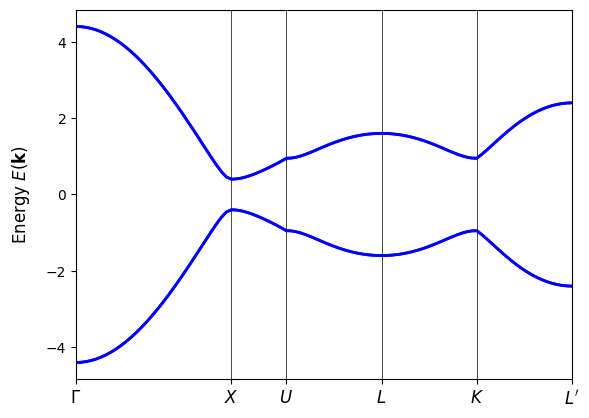

In [5]:
nodes = [
    [0,0,0], [0, 1/2, 1/2], [1/4, 5/8, 5/8],
    [1/2, 1/2, 1/2],[3/4, 3/8, 3/8],[1/2, 0, 0]
    ]
label = (r'$\Gamma$',r'$X$',r'$U$',r'$L$',r'$K$',r'$L^\prime$')
my_model.plot_bands(k_nodes=nodes, nk=101, k_node_labels=label)

In [6]:
# number of k-points along each direction in 2D grid
nk = 101  # choose nk odd when including endpoint to include k_i = 1/2, and nk even when excluding endpoint

# To include endpoint (k_i = 1), use endpoint=True
k_vals = np.linspace(0, 1, nk, endpoint=True)    # <--- include endpoint
# k_vals = np.linspace(0, 1, nk, endpoint=False) # <--- exclude endpoint

k_points = np.zeros((nk, nk, 2, 3))
for j, k2 in enumerate([0, 1/2]):
  for idx0, k0 in enumerate(k_vals):
    for idx1, k1 in enumerate(k_vals):
      k_points[idx0, idx1, j, :] = [k0, k1, k2]

mesh = Mesh(dim_k=3, axis_types=['k', 'k', 'k'])
mesh.build_custom(points=k_points)
# mesh.wind_bz(0, 0)  # <--- used if excluding endpoint
# mesh.wind_bz(1, 1)  # <--- used if excluding endpoint
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 3 k-dim(s) + 0 λ-dim(s)
Number of mesh points: 20402
Full shape: (101, 101, 2, 3)
k-axes: [Axis(type=k, name=k_0, size=101), Axis(type=k, name=k_1, size=101), Axis(type=k, name=k_2, size=2)]
λ-axes: []
Is a torus in k-space (all k-axes wind BZ): no
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
BZ-winding axes: (axis 0 winds component 0), (axis 1 winds component 1)
Endpoint axes: (axis 0 contains endpoint of component 0), (axis 1 contains endpoint of component 1)


In [7]:
wfa = WFArray(my_model.lattice, mesh, nspin=2)
wfa.solve_model(my_model)

In [8]:
hwfc = wfa.berry_phase(mu=1, state_idx=[0,1], contin=True, berry_evals=True)/(2*np.pi)

Text(0, 0.5, 'HWF center $\\bar{s}_2$')

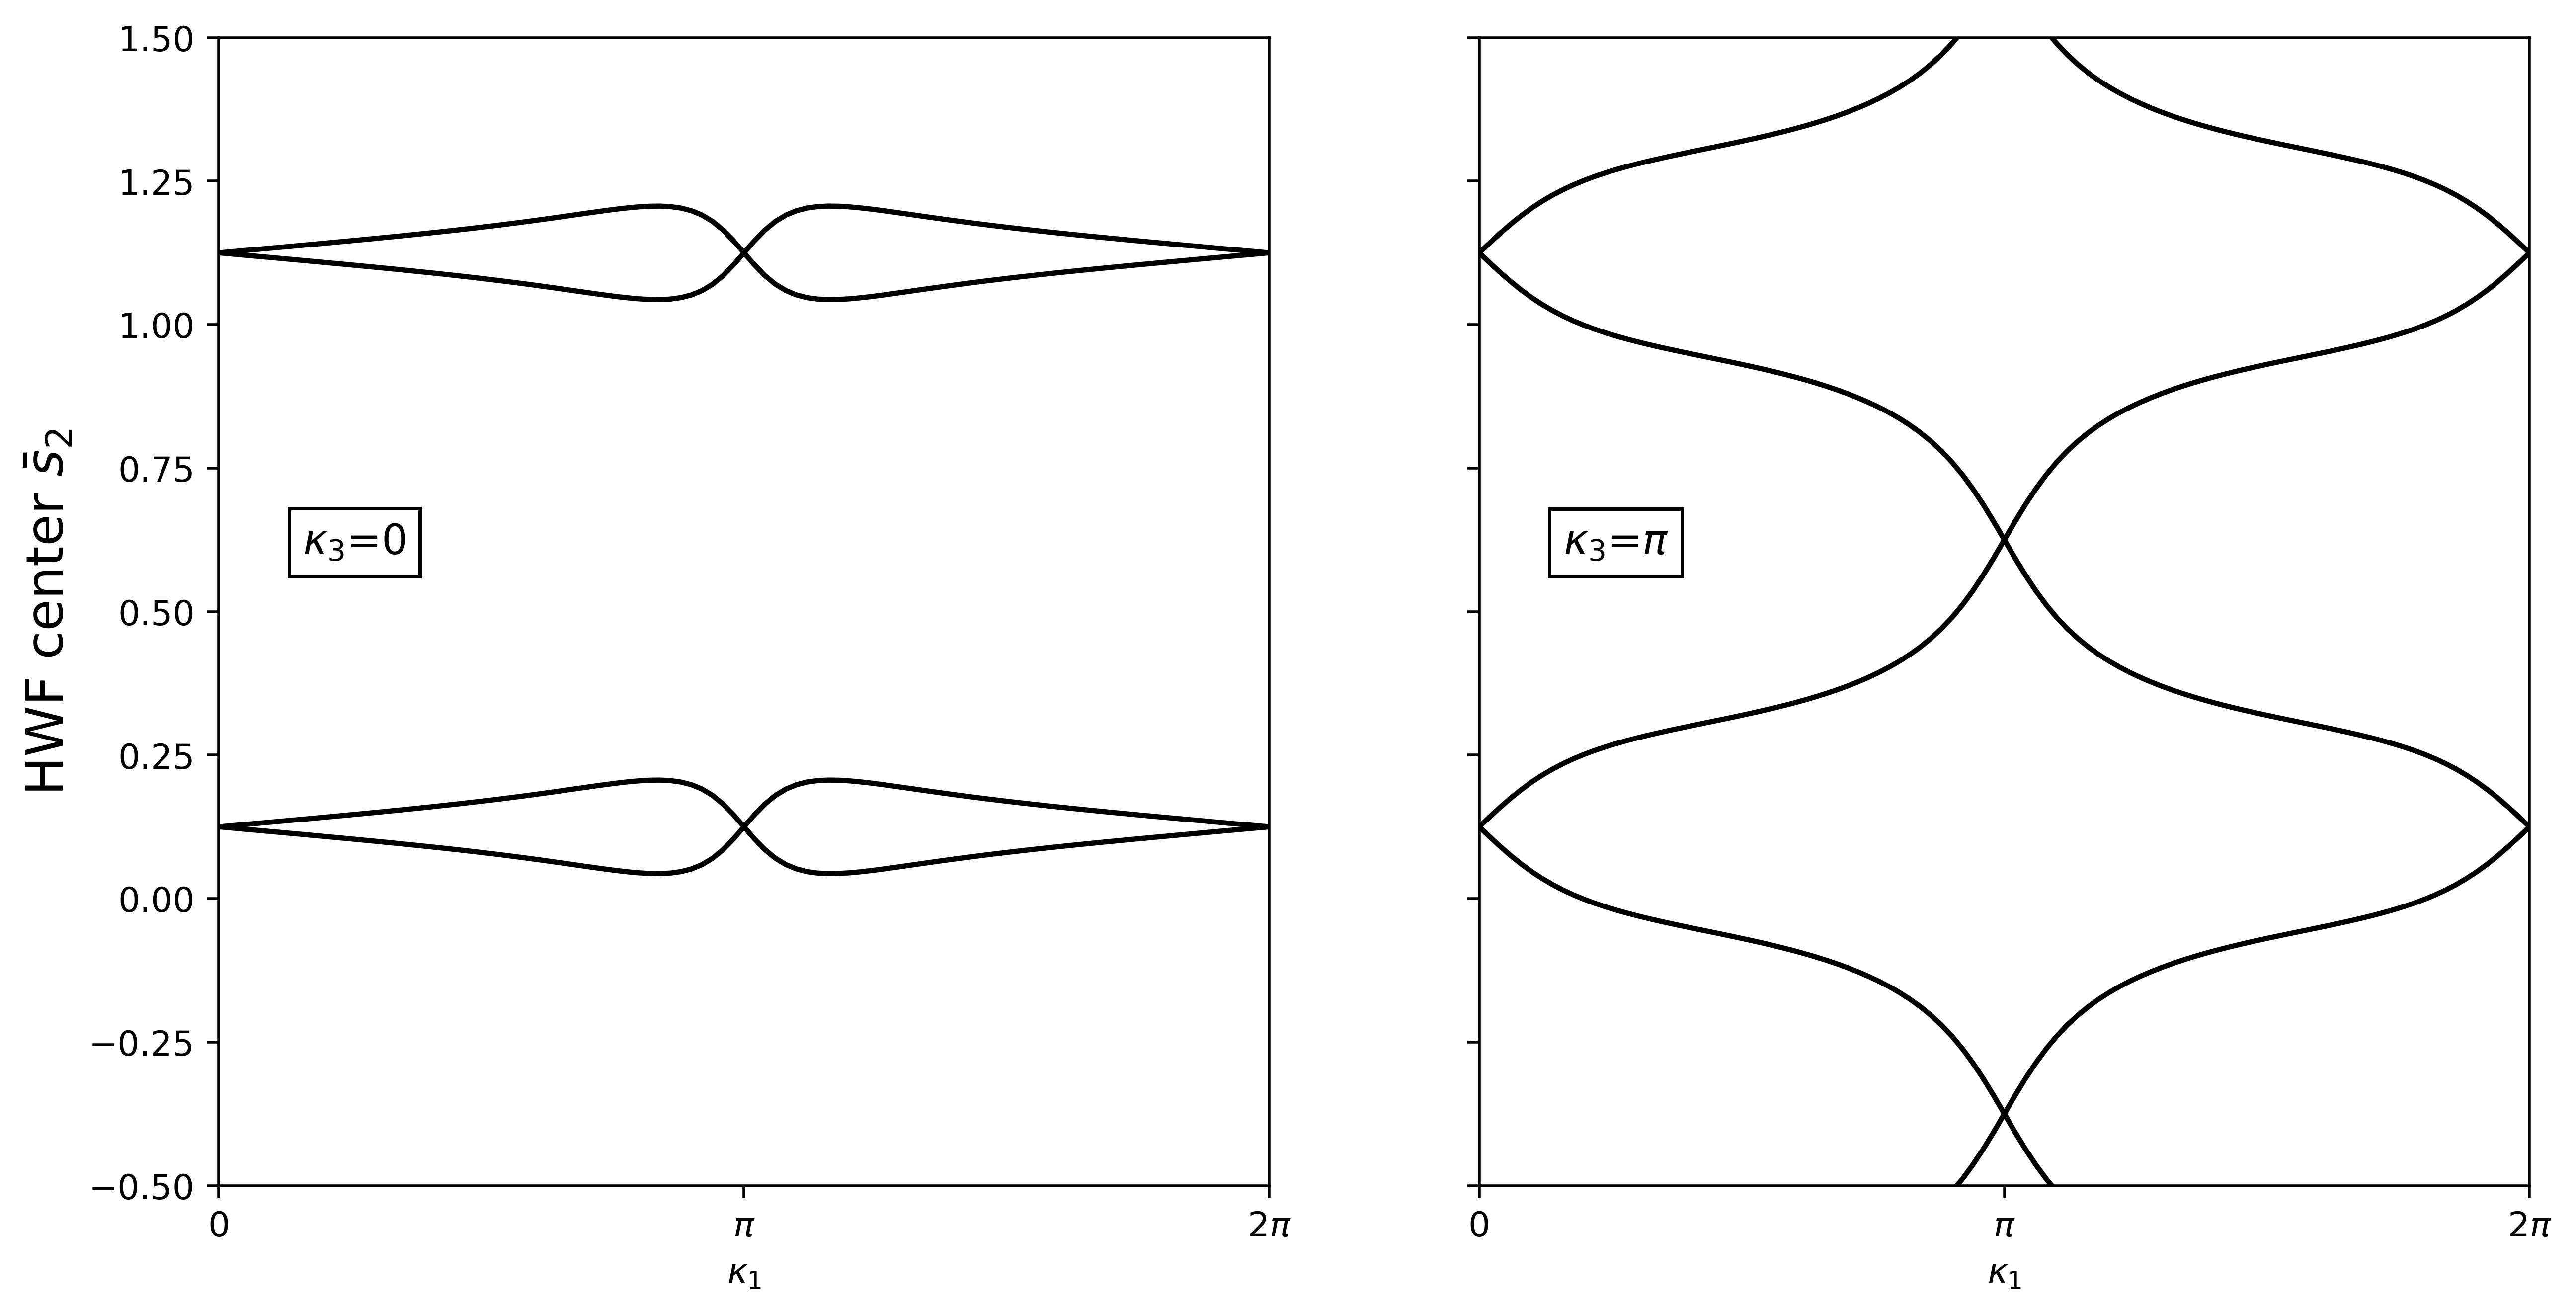

In [9]:
# initialize plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True, dpi=500)

labels = [r'$\kappa_3$=0', r'$\kappa_3$=$\pi$']
for j in range(2):
  ax[j].set_xlim([0, 1])
  ax[j].set_xticks([0, 0.5, 1])
  ax[j].set_xticklabels([0, r"$\pi$", r"$2\pi$"])
  ax[j].set_xlabel(r"$\kappa_1$")
  ax[j].set_ylim(-0.5, 1.5)
  ax[j].text(0.08, 0.60, labels[j], size=12, bbox=dict(facecolor='w', edgecolor='k'))

  for n in range(2):
    for shift in [-1, 0, 1]:
      ax[j].plot(k_vals, hwfc[:, j, n]+shift, color='k')

ax[0].set_ylabel(r"HWF center $\bar{s}_2$", size=15)

In [10]:
fin_model = my_model.make_finite(periodic_dirs=[0], num_cells=[20])

(<Figure size 800x600 with 1 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

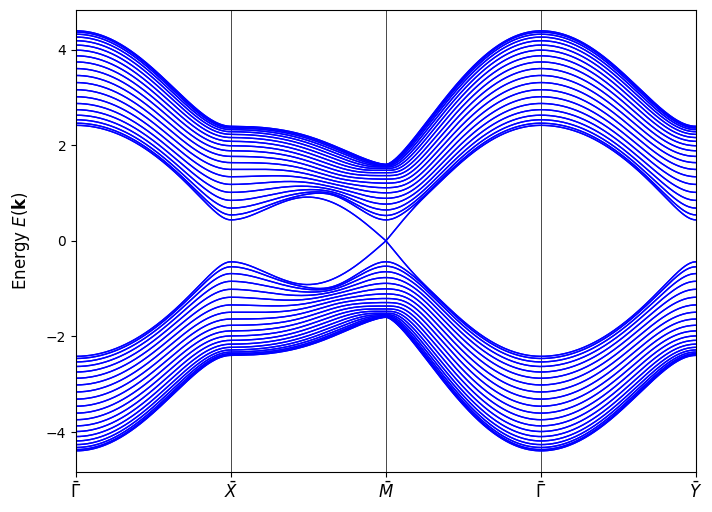

In [11]:
k_nodes = [[0, 0], [0.5, 0], [0.5, 0.5], [0, 0], [0, 0.5]]
k_labels = [r"$\bar{\Gamma}$", r"$\bar{X}$", r"$\bar{M}$", r"$\bar{\Gamma}$", r"$\bar{Y}$"]

fig, ax = plt.subplots(figsize=(8, 6))
fin_model.plot_bands(k_nodes=k_nodes, k_node_labels=k_labels, lw=1, nk=500, fig=fig, ax=ax)